# Day 4-02｜YOLO 球追蹤預覽
> Python 籃球運動資料分析課程  
> 直接讀取 `assets/converted/` 內的影片，使用 YOLO 模型搭配 supervision / ByteTrack 產生動態預覽。  
> 修課背景：具備基礎 Python 語法即可；不預設電腦視覺或運動資料分析經驗。

## 學習目標
- 確認 YOLO 模型到底會不會在真實影片中抓到球。
- 先從同一支 converted 影片抽 5 個 frame 做 sanity check，再看影片上的 ByteTrack 結果。
- 理解 object detector 與 ByteTrack 接起來後，畫面上會多出哪些視覺化資訊。
- 為後續姿態分析與球軌跡整合建立同一支影片的 ball tracking 基礎。

## 完成產出
- `assets/results/d4_02_test_infer_grid.png`
- `assets/results/d4_02_bytetrack_ball_preview.mp4`
- `assets/results/d4_02_bytetrack_ball_preview.json`


## 執行階段提醒
如果你是在 Google Colab 操作，請同學優先選擇 **T4 GPU**。  
這個單元會直接跑 YOLO detector 與 ByteTrack 預覽，所以影片解析度越高、frame 越多，執行時間也會跟著增加。


## 課程流程
1. 讀取 `assets/converted/` 內第一支 converted 影片。
2. 載入已提供的 YOLO 模型。
3. 先從同一支影片抽 5 個 frame 做 inference sanity check。
4. 再產生 supervision + ByteTrack 動態預覽影片。
5. 將球的追蹤結果輸出成 JSON，供 Day 4-04 使用。


In [18]:
from pathlib import Path
import subprocess
import sys

COURSE_ROOT_HINT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

COURSE_ROOT = bootstrap_course_repo(COURSE_ROOT_HINT)


課程根目錄: H:\Repos\basketball-hackathon-course
素材資料夾: H:\Repos\basketball-hackathon-course\assets
工具模組: H:\Repos\basketball-hackathon-course\src


In [20]:
import cv2
import numpy as np

from src.cv_utils import save_image_rgb, show_image, side_by_side
from src.video_utils import display_video_in_notebook, list_videos, pick_first_converted_video
from src.yolo_utils import (
    ball_detector_model_path,
    draw_detection_records,
    load_yolo_model,
    read_video_frame,
    run_detector_on_image,
    write_bytetrack_preview_video,
)

converted = list_videos(COURSE_ROOT / "assets" / "converted")
video_path = pick_first_converted_video(COURSE_ROOT)
model_path = ball_detector_model_path(COURSE_ROOT)
SANITY_CONF = 0.03
PREVIEW_CONF = 0.005
PREVIEW_IMGSZ = 1280
HOLD_LAST_BALL_FRAMES = 4
model = load_yolo_model(model_path)
model_names = getattr(model, "names", {}) or {}
class_names_override = (
    [str(model_names[idx]) for idx in sorted(model_names)]
    if isinstance(model_names, dict)
    else list(model_names)
)
keep_class_names = [name for name in class_names_override if name.lower() == "ball"]
if not keep_class_names:
    keep_class_names = ["Ball", "ball", "basketball"]

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise FileNotFoundError(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
cap.release()

print("converted videos:", [p.name for p in converted])
print("using video:", video_path)
print("model path:", model_path)
print("model class names:", class_names_override)
print("keep class names:", keep_class_names)
print("sanity conf:", SANITY_CONF)
print("preview conf:", PREVIEW_CONF)
print("preview imgsz:", PREVIEW_IMGSZ)
print("hold last ball frames:", HOLD_LAST_BALL_FRAMES)
print("total frames:", total_frames)


converted videos: ['video_001.mp4']
using video: H:\Repos\basketball-hackathon-course\assets\converted\video_001.mp4
model path: H:\Repos\basketball-hackathon-course\assets\models\detectors\yolo26n_basketball_player_best.pt
model class names: ['ball', 'ball-in-basket', 'number', 'player', 'player-in-possession', 'player-jump-shot', 'player-layup-dunk', 'player-shot-block', 'referee', 'rim']
keep class names: ['ball']
total frames: 1117


## Step 1｜先從 converted 影片抽 5 個 frame 做 inference sanity check

如果這 5 個 frame 大多都能抓到球，但 ByteTrack 影片還是很不穩，通常代表是：

- 球速太快導致 motion blur
- 球只出現少數 frame
- 追蹤器在球消失幾幀後接不起來

如果連這 5 個 frame 都幾乎抓不到球，就先不要急著看 ByteTrack；代表 detector 本身就還沒抓穩。


{'frame': 0, 'detections': 0, 'classes': [], 'confidences': []}
{'frame': 45, 'detections': 0, 'classes': [], 'confidences': []}
{'frame': 90, 'detections': 1, 'classes': ['ball'], 'confidences': [0.199]}
{'frame': 135, 'detections': 1, 'classes': ['ball'], 'confidences': [0.125]}
{'frame': 180, 'detections': 1, 'classes': ['ball'], 'confidences': [0.11]}
saved grid: H:\Repos\basketball-hackathon-course\assets\results\d4_02_test_infer_grid.png


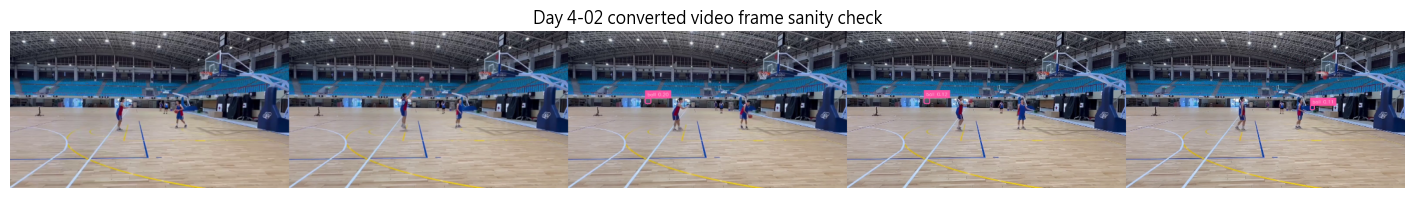

In [21]:
if total_frames <= 0:
    raise RuntimeError("無法取得影片總 frame 數。")

sample_stop = max(0, min(total_frames - 1, 180))
frame_indices = sorted({int(v) for v in np.linspace(0, sample_stop, num=5)})
while len(frame_indices) < 5 and frame_indices[-1] < total_frames - 1:
    frame_indices.append(frame_indices[-1] + 1)
frame_indices = frame_indices[:5]

rendered_tiles = []
summary_rows = []
for frame_index in frame_indices:
    image_rgb = read_video_frame(video_path, frame_index=frame_index)
    detections, _ = run_detector_on_image(
        model_path,
        image_rgb,
        conf=SANITY_CONF,
        imgsz=PREVIEW_IMGSZ,
        frame_index=frame_index,
        class_names_override=class_names_override,
    )
    detections = [det for det in detections if det.class_name in keep_class_names]
    vis_rgb = draw_detection_records(image_rgb, detections)
    rendered_tiles.append(vis_rgb)
    summary_rows.append({
        "frame": frame_index,
        "detections": len(detections),
        "classes": [det.class_name for det in detections],
        "confidences": [round(det.confidence, 3) for det in detections],
    })
    print(summary_rows[-1])

row_top = side_by_side(rendered_tiles[0], rendered_tiles[1], max_width=2200)
row_top = side_by_side(row_top, rendered_tiles[2], max_width=2200)
row_bottom = side_by_side(rendered_tiles[3], rendered_tiles[4], max_width=2200)
grid_rgb = side_by_side(row_top, row_bottom, max_width=2200)

grid_path = COURSE_ROOT / "assets" / "results" / "d4_02_test_infer_grid.png"
save_image_rgb(grid_path, grid_rgb)
print("saved grid:", grid_path)
show_image(grid_rgb, title="Day 4-02 converted video frame sanity check", figsize=(18, 12))


## Step 2｜再看 converted 影片上的 supervision + ByteTrack 預覽

如果上一步的 5 個 frame 大致正常、但這一步影片還是抓不到球，優先懷疑：

- 球在影片裡太小
- 球速太快導致 tracking 斷掉
- 球只出現少數 frame
- `conf` 還是太高

這時候先不要急著改教材流程，先看 detector 在單幀上到底有沒有抓到球。


In [22]:
preview_mp4 = COURSE_ROOT / "assets" / "results" / "d4_02_bytetrack_ball_preview.mp4"
preview_mp4, preview_records = write_bytetrack_preview_video(
    video_path=video_path,
    model_path=model_path,
    output_path=preview_mp4,
    max_frames=180,
    conf=PREVIEW_CONF,
    imgsz=PREVIEW_IMGSZ,
    class_names_override=class_names_override,
    keep_class_names=keep_class_names,
    hold_last_ball_frames=HOLD_LAST_BALL_FRAMES,
)
preview_json = preview_mp4.with_suffix(".json")

print("saved preview:", preview_mp4)
print("saved json:", preview_json)
print("records:", len(preview_records))
display_video_in_notebook(preview_mp4, width=780, muted=True, loop=True)


$ C:\Users\henry\scoop\apps\ffmpeg-shared\8.1\bin\ffmpeg.exe -y -i H:\Repos\basketball-hackathon-course\assets\results\d4_02_bytetrack_ball_preview.mp4 -an -vcodec libx264 -pix_fmt yuv420p -movflags +faststart -preset veryfast -crf 23 H:\Repos\basketball-hackathon-course\assets\results\d4_02_bytetrack_ball_preview.notebook.mp4
saved preview: H:\Repos\basketball-hackathon-course\assets\results\d4_02_bytetrack_ball_preview.mp4
saved json: H:\Repos\basketball-hackathon-course\assets\results\d4_02_bytetrack_ball_preview.json
records: 7


## 本單元產出檔案

- `assets/results/d4_02_test_infer_grid.png`：從 converted 影片抽 5 個 frame 的 inference 結果。
- `assets/results/d4_02_bytetrack_ball_preview.mp4`：YOLO + ByteTrack 預覽影片。
- `assets/results/d4_02_bytetrack_ball_preview.json`：每一個 tracked detection 的紀錄。
